# Decision Trees:
It predicts an outcome by asking a sequence of if-then questions  about the input features.

## Impurity Metrix 
### Entropy
Measures the impurity, disorder, or uncertainty in a dataset
### Gini Impurity
Measures the likelihood of a random element being misclassifies in a dataset.

### Information Gain:
- Information Gain (IG) measure is used to decide which feature to split on.
- IG = entropy of parent - weighted entropy of children
### Gini Gain:
- Gini impurity of root node - weighted GI of children

### Pruning
Pruning is a technique used in DT to remove parts of the tree that are unnecessary, in order to reduce overfitting and improve performance on unseen data.
#### Common Pruning Rules:
- **max_depth** - Stop Splitting whhen the tree reaches max depth
- **min_samples_split** - node must contain at least N samples to be split
- **min_samples_leaf** = leaf must contain at least N samples
- **max_leaf_nodes** - Limit total number of leaf nodes
- **min_impurity_decreases** - Only split if impurity reduction exceeds a threshold

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [54]:
titanic = sns.load_dataset("titanic")

In [55]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [56]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [57]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [58]:
# Missing Data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [59]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [60]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])  # male = 1, female = 0
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [61]:
X = titanic[features]
y = titanic[target]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 41
)

In [63]:
X_train.head()

,pclass,sex,fare,embarked,age
464,3,1,8.0500,2,28.0
451,3,1,19.9667,2,28.0
62,1,1,83.4750,2,45.0
705,2,1,26.0000,2,39.0
712,1,1,52.0000,2,48.0


In [64]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7686567164179104


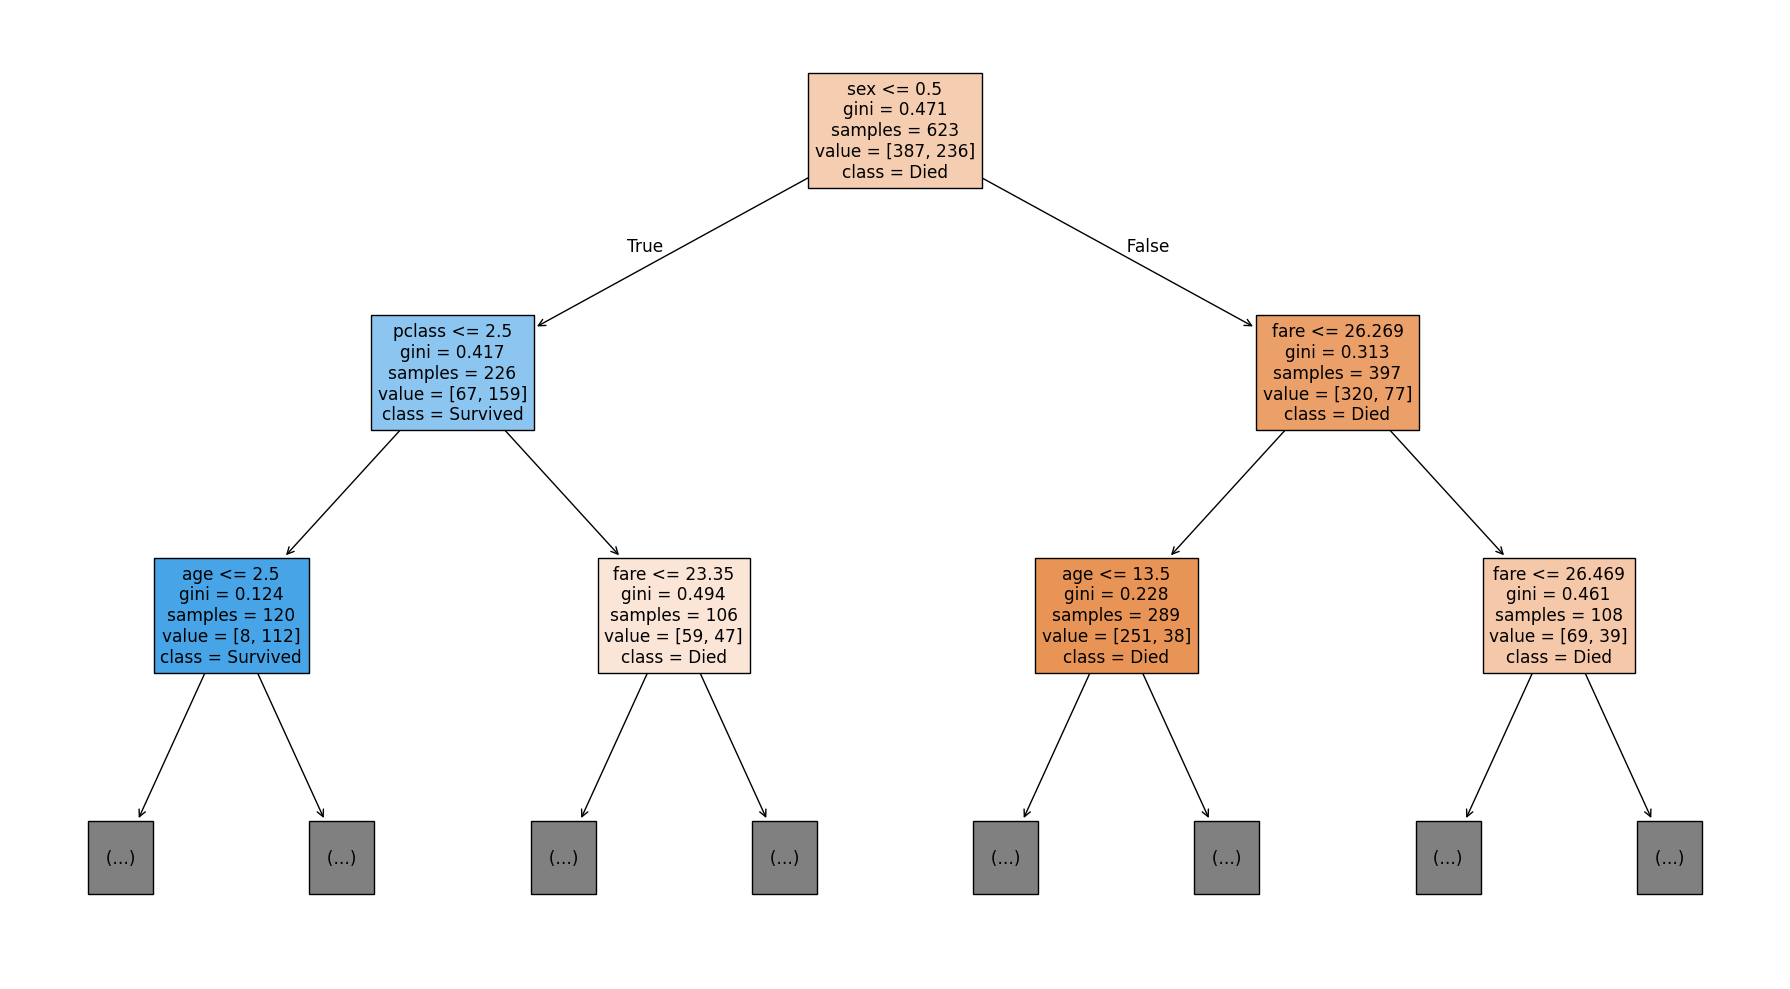

In [66]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    max_depth = 2
)
plt.tight_layout()
plt.show()

### Decision Tree with Pre- Pruning

for depth = 2, accuracy = 0.7835820895522388
for depth = 3, accuracy = 0.8507462686567164
for depth = 4, accuracy = 0.8395522388059702


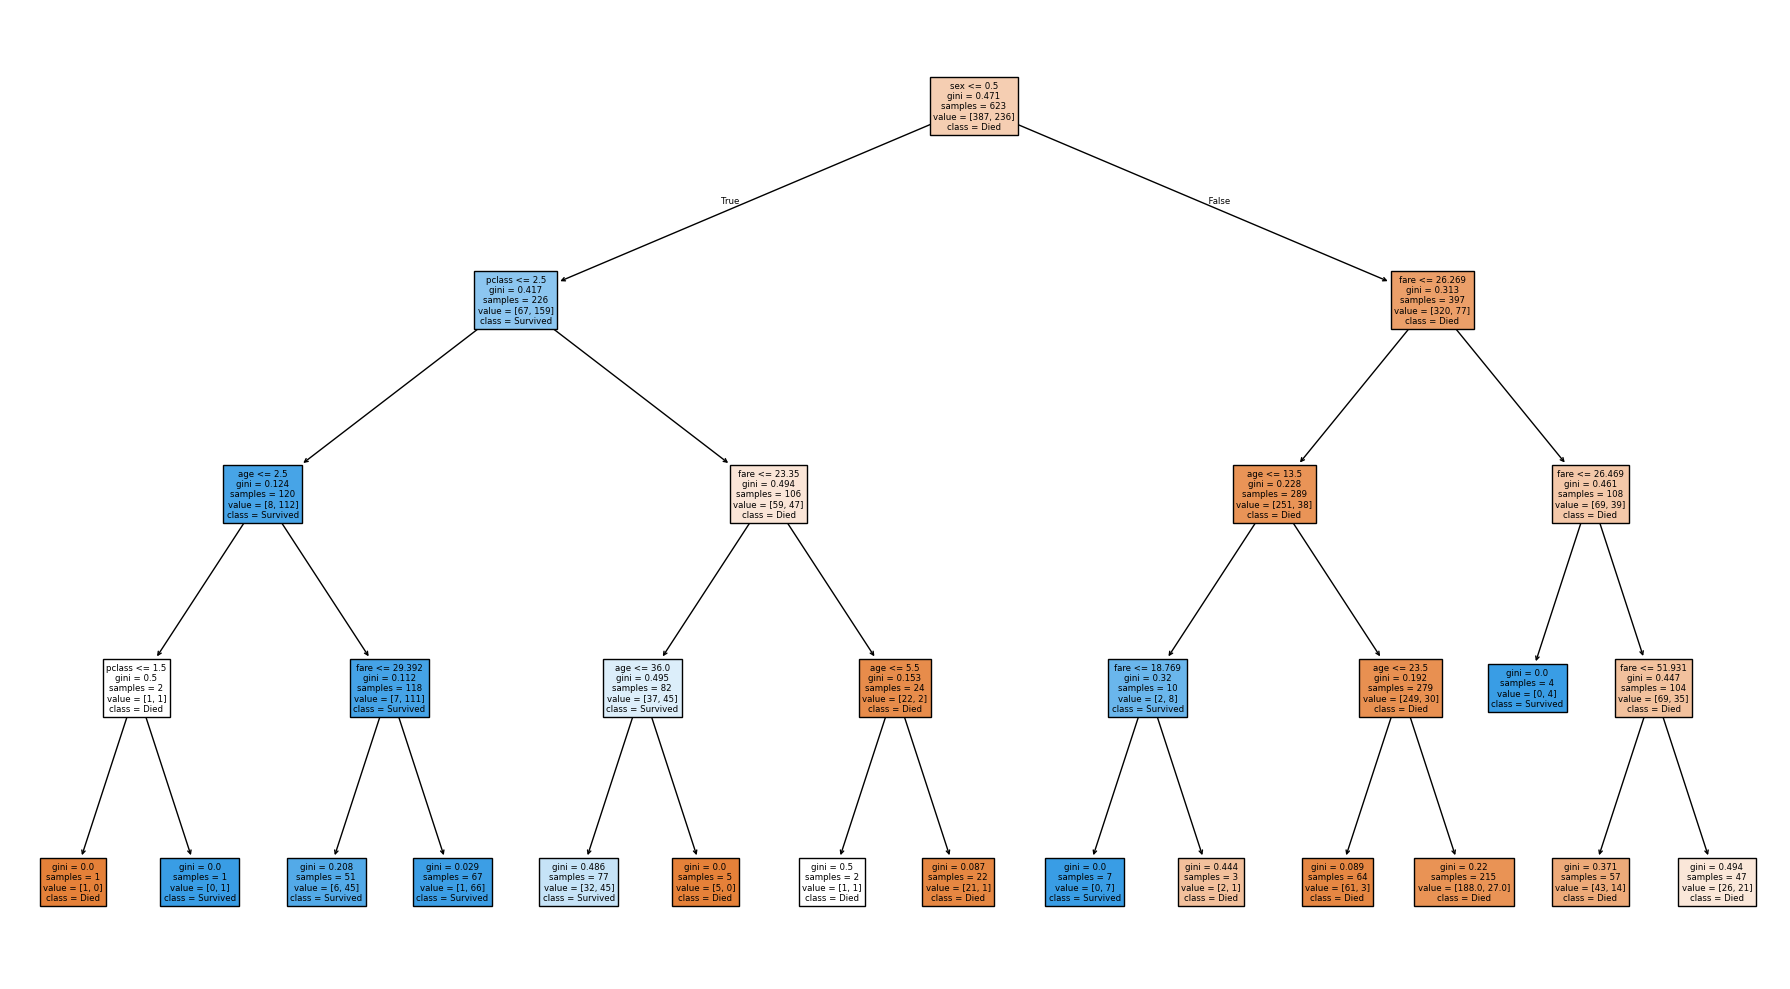

for depth = 5, accuracy = 0.8208955223880597
for depth = 6, accuracy = 0.8022388059701493
for depth = 7, accuracy = 0.8134328358208955
for depth = 8, accuracy = 0.8171641791044776
for depth = 9, accuracy = 0.7835820895522388
for depth = 10, accuracy = 0.7873134328358209


In [67]:
max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy = {acc}")

    if depth == 4:
        plt.figure(figsize = (18, 10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
        )
        plt.tight_layout()
        plt.show()

for sample split = 5, accuracy = 0.8395522388059702
for sample split = 10, accuracy = 0.8395522388059702
for sample split = 15, accuracy = 0.8507462686567164


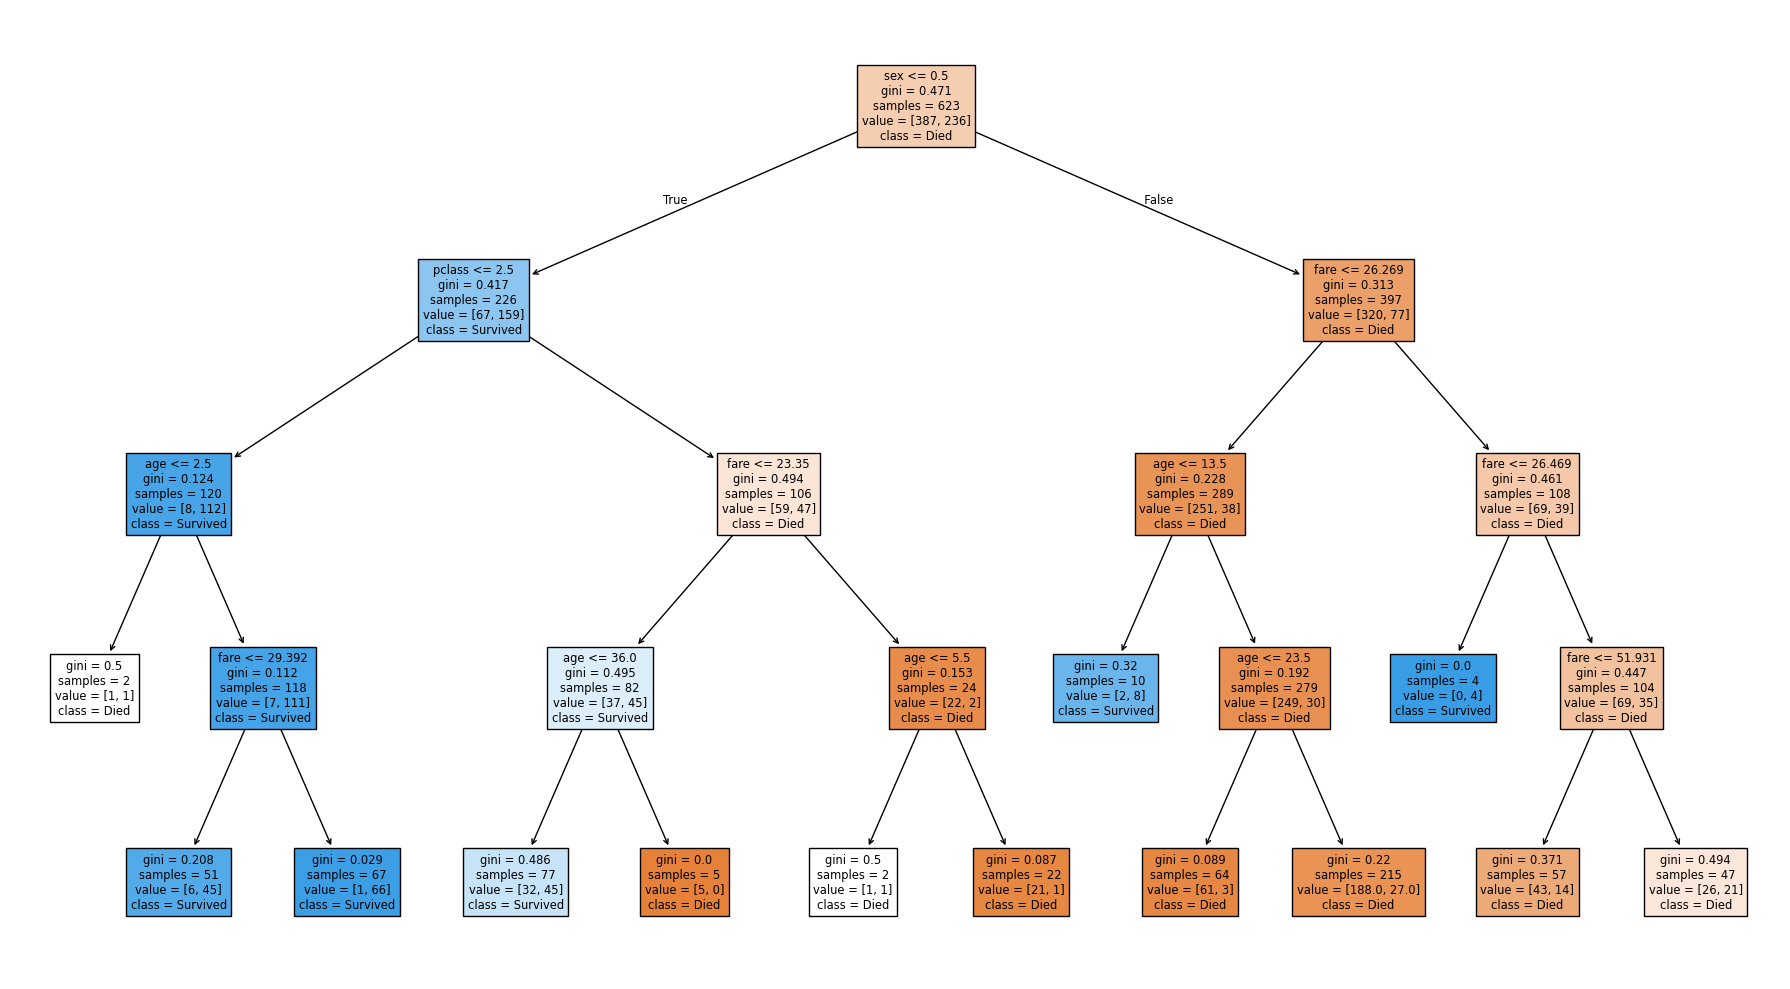

for sample split = 20, accuracy = 0.8507462686567164
for sample split = 25, accuracy = 0.8507462686567164
for sample split = 30, accuracy = 0.8507462686567164


In [68]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth = 4, min_samples_split = split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for sample split = {split}, accuracy = {acc}")
    
    if split == 15:
        plt.figure(figsize = (18, 10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
        )
        plt.tight_layout()
        plt.show()

### Decision Tree with Post- Pruning

In [69]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [70]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alpha = path.ccp_alphas

print(ccp_alpha)

[0.00000000e+00 3.56696986e-05 8.02568218e-05 1.26721298e-04
 2.33050662e-04 2.59415990e-04 4.07653698e-04 4.81540931e-04
 4.99375780e-04 5.35045479e-04 5.35045479e-04 8.02568218e-04
 8.56072766e-04 9.86861661e-04 1.01224820e-03 1.05411945e-03
 1.11591799e-03 1.11774345e-03 1.11786288e-03 1.20385233e-03
 1.20728211e-03 1.21276975e-03 1.21601245e-03 1.25716980e-03
 1.28410915e-03 1.33761370e-03 1.39545645e-03 1.40084634e-03
 1.43617471e-03 1.47137507e-03 1.49048383e-03 1.52175273e-03
 1.55776262e-03 1.59036279e-03 1.65207025e-03 1.74781523e-03
 1.81349549e-03 1.83617880e-03 1.83788122e-03 1.91277099e-03
 1.92616372e-03 1.99201548e-03 2.09922150e-03 2.14018192e-03
 2.18882241e-03 2.40770465e-03 2.50970594e-03 2.80898876e-03
 2.99625468e-03 3.23864650e-03 3.57493764e-03 4.88542834e-03
 5.14792728e-03 5.44305881e-03 1.29122503e-02 1.40844799e-02
 4.33711850e-02 1.20056699e-01]


In [71]:
# train model for all alphas

trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42, ccp_alpha = alpha)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    trees.append((model, alpha))

In [72]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha
        

In [73]:
best_alpha

np.float64(0.004885428335539474)

In [74]:
best_acc

0.8507462686567164

In [75]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


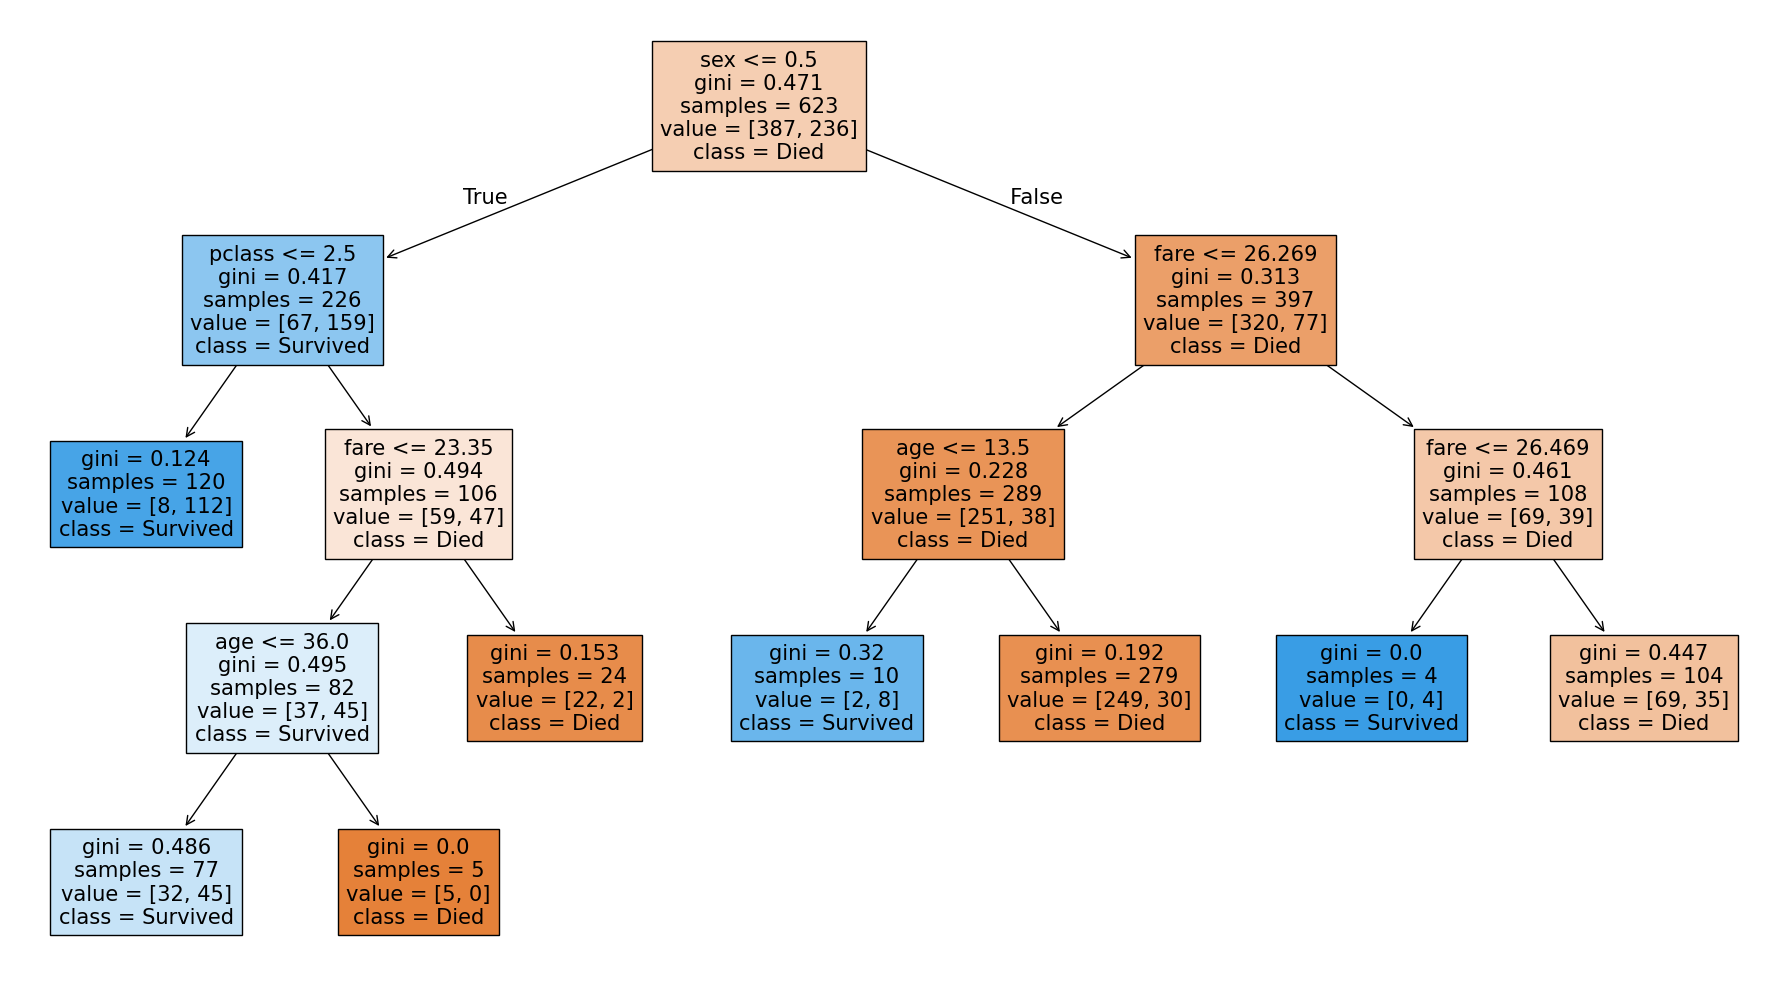

In [76]:
plt.figure(figsize = (18, 10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
)
plt.tight_layout()
plt.show()

In [79]:
print(best_model.score(X_test, y_test))


0.8507462686567164
